In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("pokemon.csv")
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

In [4]:
df.shape

(801, 41)

In [5]:
df.describe

<bound method NDFrame.describe of                        abilities  against_bug  against_dark  against_dragon  \
0    ['Overgrow', 'Chlorophyll']         1.00           1.0             1.0   
1    ['Overgrow', 'Chlorophyll']         1.00           1.0             1.0   
2    ['Overgrow', 'Chlorophyll']         1.00           1.0             1.0   
3       ['Blaze', 'Solar Power']         0.50           1.0             1.0   
4       ['Blaze', 'Solar Power']         0.50           1.0             1.0   
..                           ...          ...           ...             ...   
796              ['Beast Boost']         0.25           1.0             0.5   
797              ['Beast Boost']         1.00           1.0             0.5   
798              ['Beast Boost']         2.00           0.5             2.0   
799              ['Prism Armor']         2.00           2.0             1.0   
800               ['Soul-Heart']         0.25           0.5             0.0   

     against_elec

In [6]:
df.isnull().sum()

abilities              0
against_bug            0
against_dark           0
against_dragon         0
against_electric       0
against_fairy          0
against_fight          0
against_fire           0
against_flying         0
against_ghost          0
against_grass          0
against_ground         0
against_ice            0
against_normal         0
against_poison         0
against_psychic        0
against_rock           0
against_steel          0
against_water          0
attack                 0
base_egg_steps         0
base_happiness         0
base_total             0
capture_rate           0
classfication          0
defense                0
experience_growth      0
height_m              20
hp                     0
japanese_name          0
name                   0
percentage_male       98
pokedex_number         0
sp_attack              0
sp_defense             0
speed                  0
type1                  0
type2                384
weight_kg             20
generation             0


In [11]:
df = df[['type1','weight_kg','height_m','is_legendary']]
df = df.dropna()

In [12]:
df.isnull().sum()

type1           0
weight_kg       0
height_m        0
is_legendary    0
dtype: int64

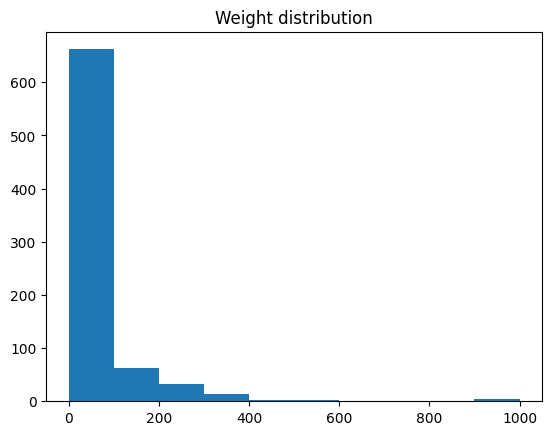

In [13]:
plt.hist(df['weight_kg'])
plt.title("Weight distribution")
plt.show()

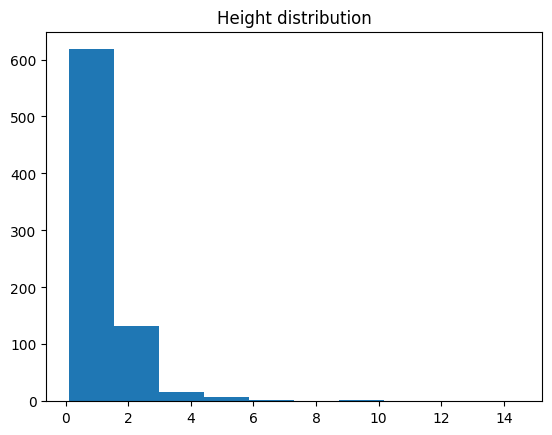

In [14]:
plt.hist(df['height_m'])
plt.title("Height distribution")
plt.show()

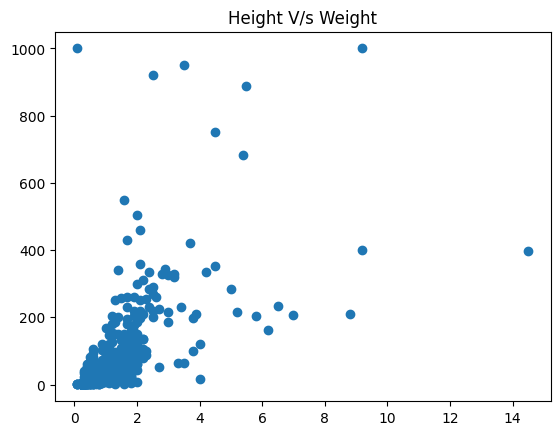

In [17]:
plt.scatter(df['height_m'],df['weight_kg'])
plt.title("Height V/s Weight")
plt.show()

<Axes: xlabel='is_legendary', ylabel='count'>

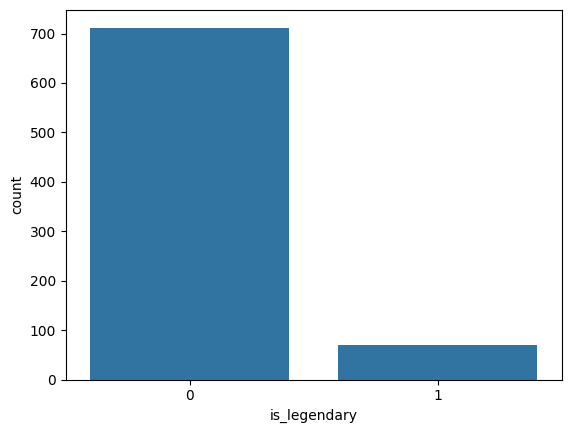

In [18]:
sns.countplot(x="is_legendary", data = df)

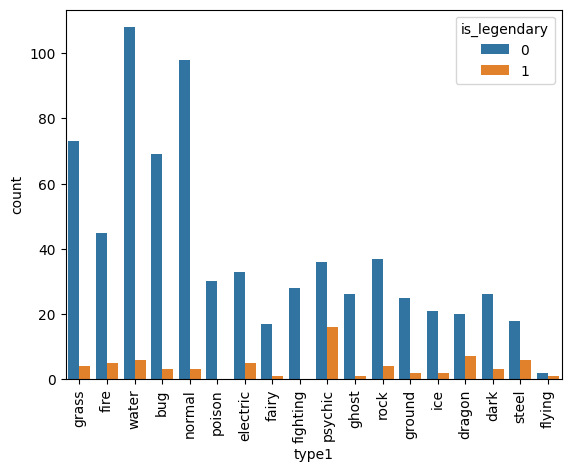

In [22]:
sns.countplot(x="type1",hue = "is_legendary", data = df)
plt.xticks(rotation = 90)
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [26]:
df['type1'] = le.fit_transform(df['type1'])
df

,type1,weight_kg,height_m,is_legendary
0,9,6.9,0.7,0
1,9,13.0,1.0,0
2,9,100.0,2.0,0
3,6,8.5,0.6,0
4,6,19.0,1.1,0
...,...,...,...,...
796,16,999.9,9.2,1
797,9,0.1,0.3,1
798,1,888.0,5.5,1
799,14,230.0,2.4,1


In [28]:
X = df[['type1','weight_kg','height_m']]
y  = df['is_legendary']

In [37]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size = 0.2, random_state = 42)


In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
model = LogisticRegression()
model.fit(Xtrain,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
y_pred = model.predict(Xtest)

In [43]:
from sklearn.metrics import accuracy_score

In [46]:
acc = accuracy_score(ytest,y_pred)
acc

0.9235668789808917